# install

In [ ]:
# # !pip install numpy==2.0.2 -q
# !pip install matplotlib==3.10.0 -q
# !pip install pandas==2.2.2 -q
# # !pip install seaborn==0.13.2 -q
# # !pip install pydantic==2.13.4 -q
# # !pip install typing_extensions==4.15.0 -q
# !pip install scikit-learn==1.6.1 -q
# !pip install xgboost==3.3.0 -q

# imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
# import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
# import numpy as np

In [ ]:
from IPython.display import Image

# Раздел 3. Обучение ML-моделей

## Постановка задачи машинного обучения
---

В терминах машинного обучения лидскоринг представляет собой задачу **бинарной классификации**: нужно обучить такую модель, которая по характеристикам объекта сможет оценивать вероятность того, что он является потенциальным. Чем ближе вероятность к 1. тем более модель уверена в том, что клиент является потенциальным - ему можно смело направлять наше предложение.

> **<font color="blue">Попробуйте сформулировать еще какие-нибудь задачи бинарной классификации.</font> А многоклассовой?**

<br>

Для обучения такой модели необходимо отобрать выборку, состоящую из 2-х частей: клиентов вашей компании (положительный класс или зеленые строки в таблице) и тех, кто точно не может являться вашим клиентом (отрицательный класс или розовые строки).

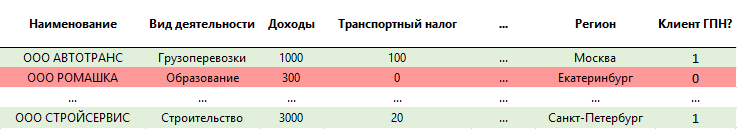

In [ ]:
Image('/content/pics/Таблица.png')

Затем эти данные **подаются в модель**, которая учит взаимосвязь между характеристиками клиентов, и классами, к которым они принадлежат.

Упрощенно процесс по нашей задаче выглядит так:<br>
Представим, что мы собрали выборку, в которой каждая компания характеризуется 2 признаками: доход и транспортный налог. У нас есть наши клиенты – зеленые точки и точно не наши клиенты – красные точки. На графике видно, что зависимость между значениями этих 2-х признаков и меткой класса существует, но мы пока не знаем ее характер.

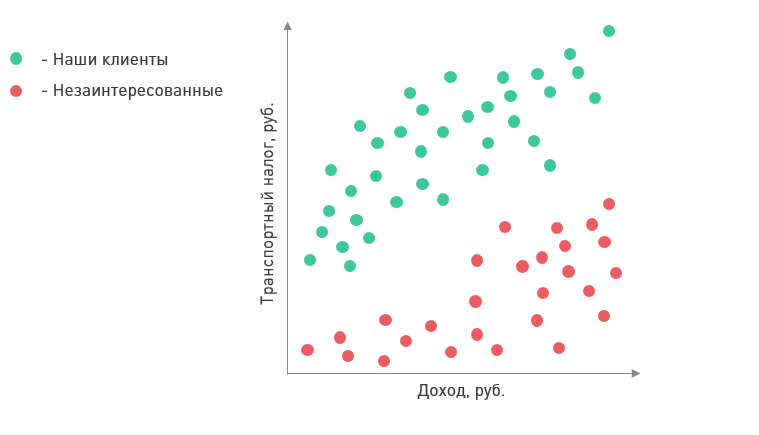

In [ ]:
Image('/content/pics/Пример_1.png')

Для оценки этой взаимосвязи, модель машинного обучения, строит гиперплоскость, которая отделяет клиентов одного класса от другого.

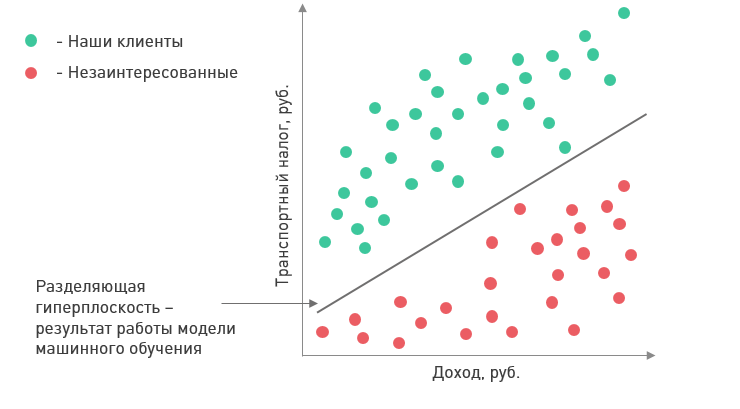

In [ ]:
Image('/content/pics/Пример_2.png')

Допустим теперь, когда модель обучена, в базу данных попала новая компания с высоким транспортным налогом, но низким доходом – это черная точка. Модель должна определить, является ли компания потенциальным клиентом или нет.

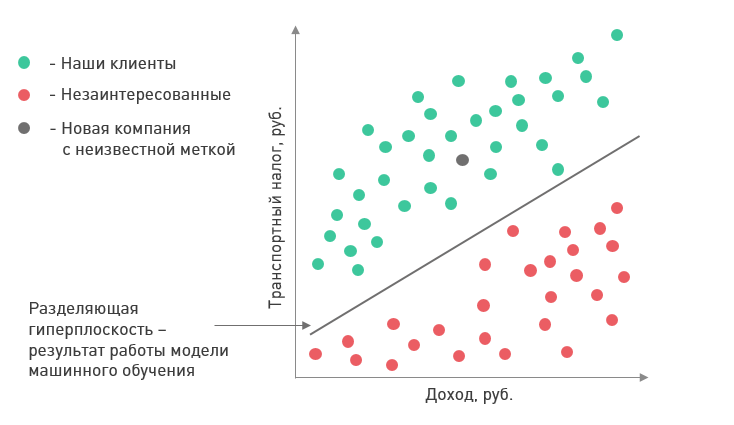

In [ ]:
Image('/content/pics/Пример_3.png')

В зависимости от того, по какую сторону от гиперплоскости находится новая компания на плоскости, ей **присваивается соответствующая метка**.
В данном случае – модель классифицирует точку положительно, клиент нам подходит, ему можно звонить. Чем дальше объект от разделяющей плоскости, тем более уверен алгоритм в своем решение и тем более высокая вероятность будет присвоена.

> **<font color="blue">Какая проблема возникает при такой постановке задачи?</font>**

<br>

У нас есть данные по нашим клиентам, но отсутствует выборка тех, кто точно не заинтересован в наших услугах, то есть нет отрицательного класса для бинарной классификации. Без отрицательного модель не сможет понять, что отличает потенциальных клиентов от тех, кому наши услуги не интересны. <br>
Эту проблему можно решить путем искусственной генерации отрицательного класса.<br>

Мы понимаем, что среди всех юридических лиц России значительная часть не имеет парка автомобилей, – это красные точки, и есть небольшая доля неизвестных, по ним мы пока суждений делать не можем – серые точки.

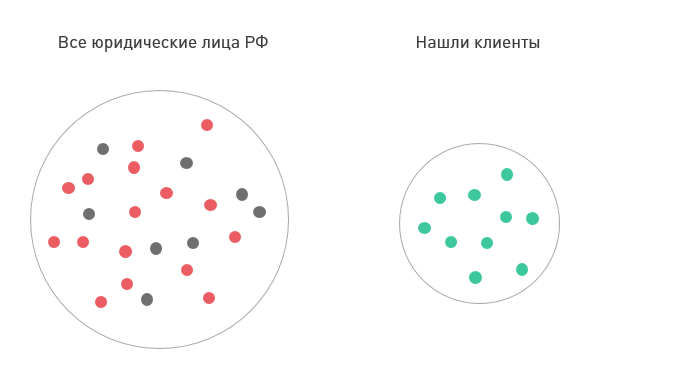

In [ ]:
Image('/content/pics/Обучающая_выборка_1.png')

Поэтому, компании для негативного класса были получены случайной выборкой нескольких тысяч компаний из этой базы, что выглядит оправданно: в эту выборку скорее попадут те, кого не интересует покупка топлива, что нам и нужно. По сути, модель должна научиться отличать нашего клиента, от случайного. <br>

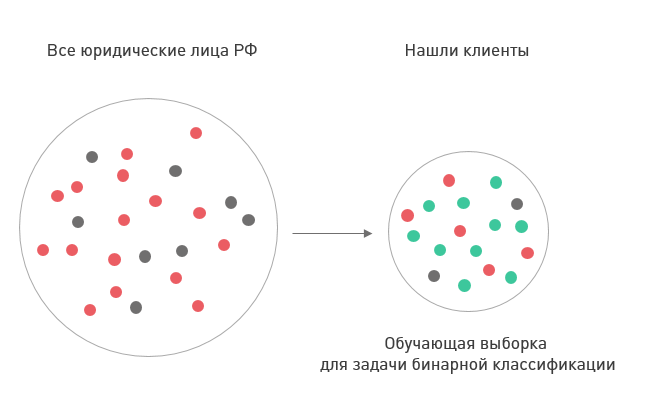

In [ ]:
Image('/content/pics/Обучающая_выборка_2.png')

**Алгоритм** решения задачи классификации:
1. Выбор метрики оценки качества модели
2. Выбор метода моделирования
3. Подгонка, обучение модели (расчет параметров)
4. Анализ точности и значимости результата

## Данные после стандартизации

In [ ]:
df = pd.read_csv('df_st.csv')
# data after standardization

In [ ]:
df = df.set_index('ClientId')

In [ ]:
df.sample(5)

,Target,Risk,Org,Age,Truck,Car,Assets,Size
ClientId,,,,,,,,
701,1,-1.566107,1.355574,-0.852715,0.432793,-0.473674,3.932769,1.005181
357,1,-1.566107,1.355574,-0.551366,-0.474545,0.767630,0.458993,-0.568837
141,0,0.827377,1.355574,-0.570201,-0.474545,2.008933,-0.341455,1.005181
226,0,0.827377,-0.737695,-0.551366,-0.474545,-0.473674,-0.460166,-0.568837
479,0,0.827377,-0.737695,-0.551366,-0.474545,-0.473674,-0.496997,-0.568837


Отделяем таргет от признаков:

In [ ]:
X = df.drop(columns=['Target'])
y = df['Target']

In [ ]:
X.head()

,Risk,Org,Age,Truck,Car,Assets,Size
ClientId,,,,,,,
1,0.827377,-0.737695,-0.551366,0.432793,-0.473674,-0.502449,-0.568837
2,-1.566107,1.355574,0.654030,0.432793,-0.473674,0.786855,1.005181
3,0.827377,1.355574,-0.250017,-0.474545,-0.473674,-0.488858,-0.568837
4,-1.566107,1.355574,0.428018,0.432793,-0.473674,0.420736,-0.568837
5,0.827377,-0.737695,0.428018,-0.474545,-0.473674,-0.486342,-0.568837


In [ ]:
y.head()

,Target
ClientId,
1,0
2,1
3,1
4,1
5,0


In [ ]:
df['Target'].value_counts(normalize=True)

,proportion
Target,
0,0.616162
1,0.383838


Выборка строго говоря несбалансированная, но дисбаланс классов незначительный. Взвешивание классов в моделях не требуется. Внутри кросс-валидации будем использовать стратифицированное деление на подвыборки, что сохранит пропорцию классов.

In [ ]:
#sns.histplot(x='Target', data=df);

## train test split

test size - 0.2 - отложенная тестовая выборка

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
y_test.shape

(179,)

train делим на train, val, val_size=0.25

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [ ]:
y_train.shape

(534,)

In [ ]:
y_valid.shape

(178,)

Итого размер подвыборок от всего датафрейма
* train size - 0.6
* valid size - 0.2
* test size - 0.2

Зачем делить выборку на подвыборки?
* **обучающую (train) выборку** используем для обучения
* **валидационную (validation) выборку** используем для подбора параметров модели
* **тестовую (test) выборку** используем для итоговой оценки метрики

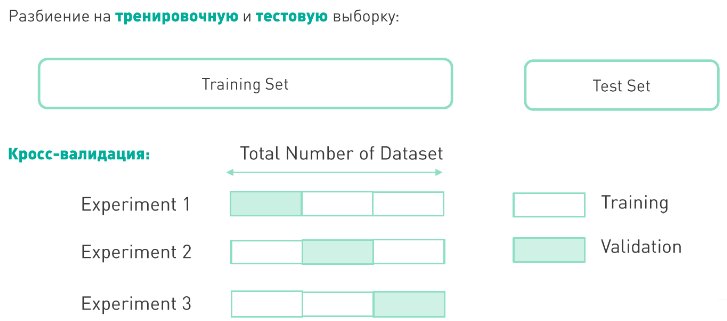

In [ ]:
Image('/content/pics/train_test.png')

## Метрики качества классификации

В задачах машинного обучения для оценки качества моделей и сравнения различных алгоритмов используются **метрики качества**.

<br>

> **<font color="green">Идея использования метрик качества в задачах классификации заключается в том, чтобы понять насколько хорошо мы угадываем классы.</font>**

<br>

Перед переходом к самим метрикам необходимо ввести важную концепцию для описания этих метрик в терминах ошибок классификации — **confusion matrix (матрица ошибок)**. <br>
Допустим, что у нас есть два класса и алгоритм, предсказывающий принадлежность каждого объекта одному из классов, тогда матрица ошибок классификации будет выглядеть следующим образом:

Прогноз\Реальные значения|$y = 1$|$y = 0$
-------------------------|-------|-------
$\hat y = 1$ |True Positive (TP)|False Positive (FP)
$\hat y = 0$|False Negative (FN)|True Negative (TN)

Здесь $\hat y$ — это ответ алгоритма на объекте, а $y$ — истинная метка класса на этом объекте.
Таким образом, ошибки классификации бывают двух видов: False Negative (FN) и False Positive (FP).

### Accuracy (аккуратность)

- Accuracy - доля объектов, в которых предсказанный класс совпал с реальным
- Можно интерпретировать как вероятность правильно предсказать класс на случайно выбранном объекте
- Не репрезентативна при несбалансированных классах

$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$

Показатель работает для сбалансированной выборки, поданной модели на вход.

### Precision (точность)

- Precision - количество правильно предсказанных объектов класса деленное на количество  объектов, которым этот класс был предсказан.

- Можно интепретировать как вероятность того, что объект, отнесенный моделью к классу, окажется объектом этого класса.

- Используем, когда важно минимизировать ложно-положительные результаты.

$Precision = \frac{TP}{TP+FP}$

*Пример: Определение спама в почте. Минимизируем FP, т.е. число обычных писем, отнесенных моделью к спаму (чтобы не снижать доверие пользователя к антиспаму).*

### Recall (полнота)

- Recall - количество правильно предсказанных объектов класса деленное на количество  объектов этого класса.

- Можно интепретировать как вероятность того, что объект  класса будет отнесен моделью к этому классу.

- Используем, когда важно минимизировать ложно-отрицательные результаты

$Recall = \frac{TP}{TP+FN}$

*Пример: Определение болезни. Минимизируем FN, т.е. пропуск моделью болезни, лучше лишний раз сделать доп. проверку, чем пропустить угрозу жизни.*

### F-мера

- $f$ мера - способ скомбинировать recall и precision в одну метрику

- $f_1 = \frac{2~precsion~х~recall}{precision~+~recall}$

- Имеет обобщение для учёта важности precision и recall $f_{\beta} = \frac{(1+\beta^2)~precsion~х~recall}{\beta^2 precision~+~recall}$

$0<\beta<1$ - предпочтение отдается точности (Precision)

$\beta >1$ - больший вес преобретает полнота (Recall)

> В нашей задаче берем метрику accuracy как основную, f1-score как дополнительную.

> **<font color="green">Выбор метрики качества основывается на бизнес-задаче и происходит до этапа моделирования.</font>**

<br>

## Models

К числу распространенных методов решения задачи классификации относятся:

* логистическая регрессия
* деревья решений
* ансамбли моделей
* и пр.

> **<font color="green">Обучение модели - это подгонка выбранной модели под имеющиеся данные, на этапе обучения происходит расчет (или подбор) числовых параметров модели.</font>**

Обучение осуществляется по следующему **алгоритму**:

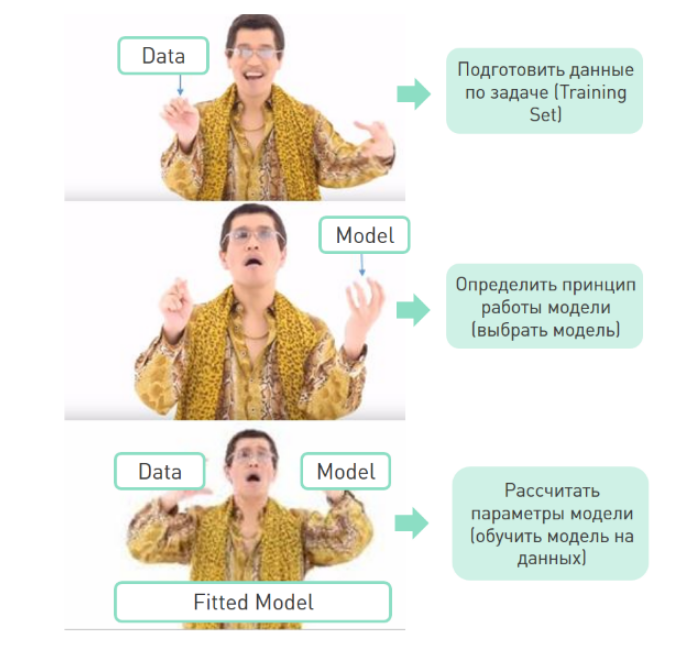

In [ ]:
Image('/content/pics/fit.png')

### LogisticRegression

Документация:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

**Кратко:** Базовая baseline модель для задачи бинарной классификации. Строит прогноз через моделирование линейных зависимостей в данных.

В классической статистике **линейная регрессия** используется для того, чтобы предсказать какое-то **непрерывное число**. Например, зная площадь квартиры и расстояние до метро, линейная модель предскажет её стоимость: 5, 10 или 20 миллионов рублей.

Но что будет, если мы попытаемся натравить линейную регрессию на **задачу классификации**? Допустим, мы пытаемся предсказать выдачу кредита, где 0 — это отказ, а 1 — одобрение.

**Линейный алгоритм** построит прямую линию. Проблема в том, что прямая линия уходит в бесконечность. Для клиента с огромной зарплатой она может предсказать значение +15, а для безработного студента выдать -42.

![](https://thecode.media/wp-content/uploads/2026/03/unnamed-2-7.png)

На графике слева линейная прямая уходит вверх и вниз, выдавая бессмысленные для нашей задачи числа. Справа — логистическая кривая (S-образная), которая аккуратно прижимает все предсказания к диапазону от 0 до 1.

Как нам интерпретировать значение -42, если мы ждем ответ «да» или «нет»? Никак. Именно поэтому математики придумали другой подход. **Логистический алгоритм** предсказывает не саму метку, а **вероятност** того, что событие произойдет. А вероятность всегда находится в строгих рамках от 0 до 1.

Модель превращает данные в вероятность в три шага — суммирует признаки умноженные на коэффициент важности, вычисляет на основе полученного логита вероятность (взятие сигмоиды) и сравнивает эту вероятность с порогом принятия решения (базово в бинарной классификации порог 0,5).

In [ ]:
model_lg = LogisticRegression(random_state=42)

Здесь и далее задаем random_state для воспроизводимости результата (фиксируем начальное значение генератора псевдослучайных чисел)

In [ ]:
# Обучаем модель на обучающей выборке
model_lg.fit(X_train, y_train)

LogisticRegression(random_state=42)

Можно оценить значимость признаков.

In [ ]:
dict(zip(model_lg.coef_.tolist()[0], X_train.columns))

{-0.9341970012639622: 'Risk',
 1.2354359185123653: 'Org',
 -0.42427552884648423: 'Age',
 -0.3118986157797699: 'Truck',
 -0.09807260610259141: 'Car',
 0.14782424866858834: 'Assets',
 0.18268835425775176: 'Size'}

Прямая связь с таргетом для положительных коэф., обратная связь с таргетом для отрицательных коэф.

In [ ]:
model_lg.intercept_

array([-0.6151665])

In [ ]:
# Строим предсказание модели на валидационной выборке
y_pred_lg = model_lg.predict(X_valid)

In [ ]:
pd.DataFrame({'Реальные значения': y_valid, 'Предсказанные значения': y_pred_lg }).head(10)

,Реальные значения,Предсказанные значения
ClientId,,
374,0,1
849,0,0
594,0,1
238,1,1
37,1,0
723,0,0
257,1,1
384,1,1
822,1,0


In [ ]:
print(classification_report(y_valid, y_pred_lg))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       112
           1       0.79      0.73      0.76        66

    accuracy                           0.83       178
   macro avg       0.82      0.81      0.81       178
weighted avg       0.82      0.83      0.82       178



> По модели LogisticRegression
- Основная метрика accuracy - 0.83.
- Средний взвешенный f1-score - 0.82.

### DecisionTreeClassifier

Документация: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

**Кратко:** Стандарт для табличных данных малого и среднего значения. У нас табличные данные малого размера. "Деревянная" модель устойчива к выбросам, находит нелинейные зависимости (в отличии от логистической регресии).

**Задача**: хотим научиться предсказывать страховать ли авто.

Есть **два класса**: страховать, не страховать

В каждой внутренней вершине записано **условие перехода** к следующей вершине.

В каждом **листе** записан прогноз (класс).

**Условия** – находится ли значение некоторого признака i левее, чем некоторый порог t? Если меньше порога – идем влево, больше порога – идем вправо.

Выбираем **критерий i и порог t** так, чтобы взвешенный разброс ответов в каждом поддереве был минимальным. Математически это определяет:

* Критерий Джинни: $H(X) = \sum_{k=1}^K p_k\cdot (1 - p_k)$
* Энтропийный критерий: $H(X) = -\sum_{k=1}^K p_k\cdot ln{p_k}$

где $p_k$ - доля $k$-ого объекта

**Прогноз** – наиболее популярный (часто встречающийся) ответ в листе.

**Критерий останова:**

* В вершину попало ≤ n объектов (рекомендация: n = 5 для маленьких выборок). Если n = 1 – переобучение.
* Задать ограничение на глубину дерева (применяется в ансамблях моделей). Можно в одной ветке задать только 3 вопроса.

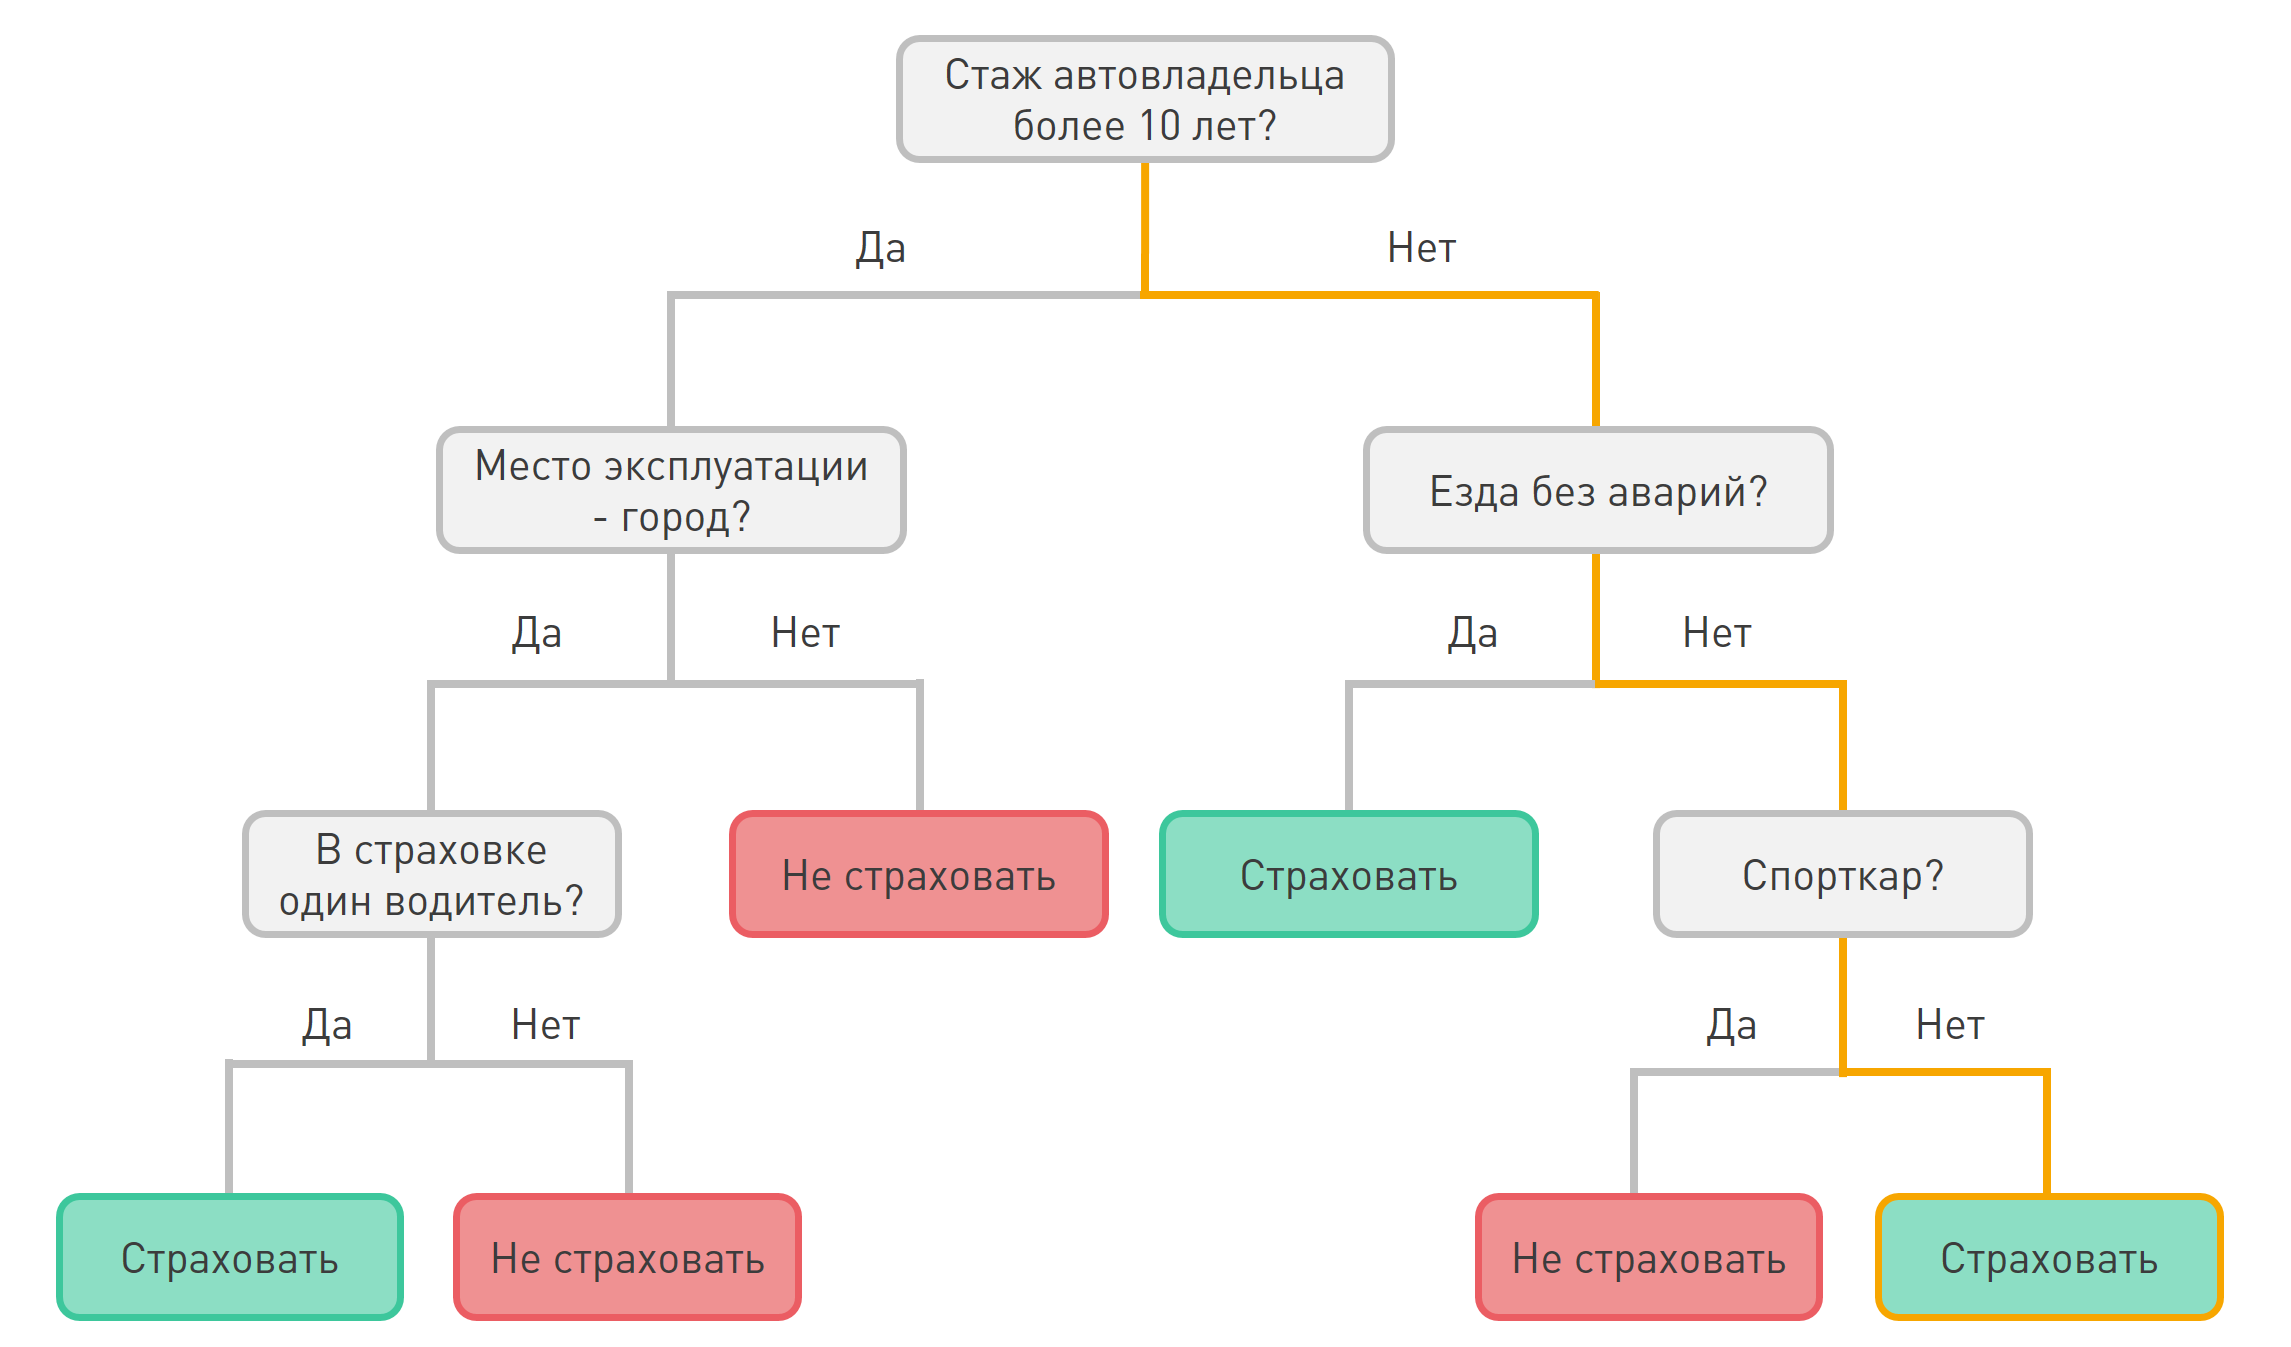

In [ ]:
Image('/content/pics/Дерево.png')

**Плюсы метода**:
	Быстрое построение модели, легкая интерпретация

**Минусы метода**:
	Низкая точность

In [ ]:
model_dt = DecisionTreeClassifier(random_state = 42)

In [ ]:
# Обучаем модель на обучающей выборке
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Модель позволяет оценить ценность каждого фактора в смысле её эффективности для разбиения (Gini importance):

In [ ]:
pd.DataFrame({'feature': X.columns,
              'importance': model_dt.feature_importances_}).sort_values('importance', ascending = False)

,feature,importance
1,Org,0.283644
5,Assets,0.279250
2,Age,0.230966
0,Risk,0.123689
3,Truck,0.035539
4,Car,0.023539
6,Size,0.023373


Чем больше значение, тем больше влияние показателя на результат. При этом все коэф. положительные.

<Axes: >

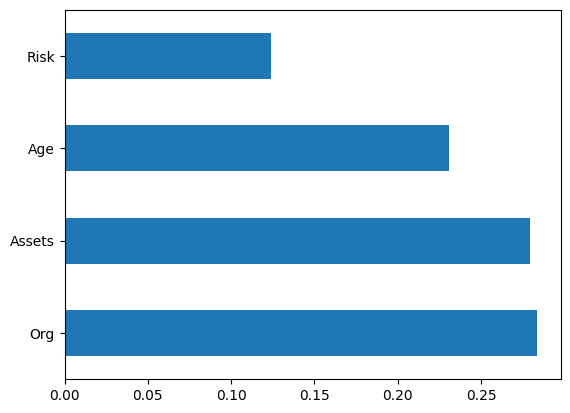

In [ ]:
# Отображение ценности в графическом виде
pd.Series(model_dt.feature_importances_, index = X.columns).nlargest(4).plot(kind='barh')

In [ ]:
# Строим предсказание модели на валидационной выборке
y_pred_dt = model_dt.predict(X_valid)

In [ ]:
pd.DataFrame({'Реальные значения': y_valid, 'Предсказанные значения': y_pred_dt}).head(10)

,Реальные значения,Предсказанные значения
ClientId,,
374,0,1
849,0,0
594,0,1
238,1,1
37,1,0
723,0,0
257,1,1
384,1,1
822,1,0


Не забываем про оценку качества:

In [ ]:
print(classification_report(y_valid, y_pred_dt))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       112
           1       0.75      0.76      0.75        66

    accuracy                           0.81       178
   macro avg       0.80      0.80      0.80       178
weighted avg       0.82      0.81      0.81       178



> По модели DecisionTree
- Основная метрика accuracy - 0.81.

- Средний взвешенный f1-score - 0.81.

Обе метрики снизились по сравнению с моделью логистической регресии.

### XGBoost

Документация: https://xgboost.readthedocs.io/en/latest/

**Кратко:** Стандарт для табличных данных. Бустинг последовательно исправляет ошибки прошлых моделей, что обычно дает прирост в качестве.

Когда мы пытаемся предсказать целевую переменную с помощью любого алгоритма машинного обучения, главные причины отличий реальной и предсказанной переменной — это noise, variance и bias. Ансамбль помогает уменьшить эти факторы (за исключением noise — это неуменьшаемая величина).

**Ансамбль**

Ансамбль — это набор предсказателей, которые вместе дают ответ (например, среднее по всем). Причина почему мы используем ансамбли — несколько предсказателей, которые пытаюсь получить одну и ту же переменную дадут более точный результат, нежели одиночный предсказатель. Техники ансамблирования впоследствии классифицируются в Бэггинг и Бустинг.

**Бустинг**

Бустинг — это техника построения ансамблей, в которой предсказатели построены не независимо, а последовательно

Это техника использует идею о том, что следующая модель будет учится на ошибках предыдущей. Они имеют неравную вероятность появления в последующих моделях, и чаще появятся те, что дают наибольшую ошибку. Предсказатели могут быть выбраны из широкого ассортимента моделей, например, деревья решений, регрессия, классификаторы и т.д. Из-за того, что предсказатели обучаются на ошибках, совершенных предыдущими, требуется меньше времени для того, чтобы добраться до реального ответа. Но мы должны выбирать критерий остановки с осторожностью, иначе это может привести к переобучению.

In [ ]:
model_xg = XGBClassifier(random_state=42, objective='binary:logistic')

In [ ]:
# Обучаем модель на обучающей выборке
model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Строим предсказание модели на валидационной выборке
y_pred_xg = model_xg.predict(X_valid)

In [ ]:
pd.DataFrame({'Реальные значения': y_valid, 'Предсказанные значения': y_pred_xg }).head(10)

,Реальные значения,Предсказанные значения
ClientId,,
374,0,1
849,0,0
594,0,1
238,1,1
37,1,0
723,0,0
257,1,1
384,1,1
822,1,0


In [ ]:
print(classification_report(y_valid, y_pred_xg))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       112
           1       0.77      0.76      0.76        66

    accuracy                           0.83       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.83      0.83      0.83       178



> По модели XGB
- Основная метрика accuracy - 0.83.
- Средний взвешенный f1-score - 0.83.

Обе метрики сопоставимы с моделью логистической регресии, при этом ср. взвеш. f1-score немного выше для модели xgboost.

> Выбираем модель xgboost.

Высокий f1-score на 1-ом классе (при этом класс более редкий) говорит о том, что модель нашла скрытые причинно-следственные связи, а не подстроилась под большинство данных.

Для модели также построим confusion matrix

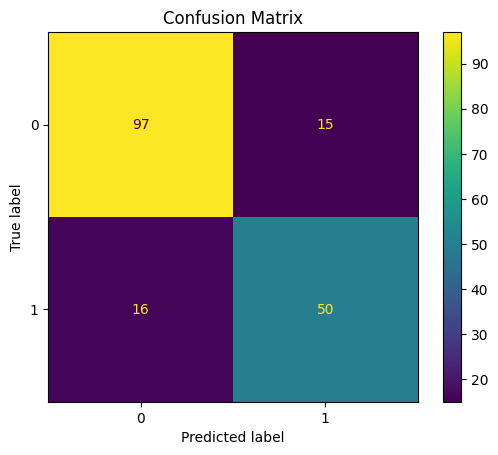

In [ ]:
cm_xg = confusion_matrix(y_valid, y_pred_xg)
disp_xg = ConfusionMatrixDisplay(confusion_matrix=cm_xg)
disp_xg.plot(cmap=plt.cm.viridis)
plt.title('Confusion Matrix')
plt.show()

Для 50 наблюдений правильно определен 1-ый класс, для 97 наблюдений правильно определен 0-ой класс. Ошибка I-го рода для 15 наблюдений (FP), ошибка II-го рода для 16 наблюдений (FN).

### Нейронные сети

На самом деле про нейросеть говорить не будем, обычно ее интерпретация для нас - это черный ящик, поэтому можно сказать что работает она вот так:

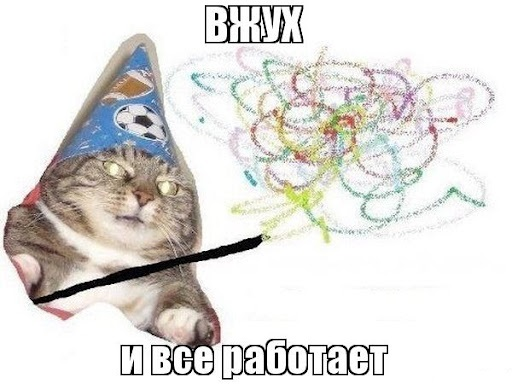

In [ ]:
Image('/content/pics/Вжух.jpg')

# Раздел 4. Кросс-валидация и подбор гиперпараметров

Кросс-валидация — это метод оценки качества модели машинного обучения, при котором доступные данные многократно разбиваются на обучающую и валидационную выборки, при этом метрика качества усредняется по числу разбиений (фолдов).

В отличие от простого однократного разделения данных (например, на 80% для обучения и 20% для теста), кросс-валидация позволяет проверить модель на всех имеющихся данных, исключая фактор случайного или «удачного» разбиения.

При выборе стратифицированного сэмплирования в подвыборках сохраняется распределение таргета.

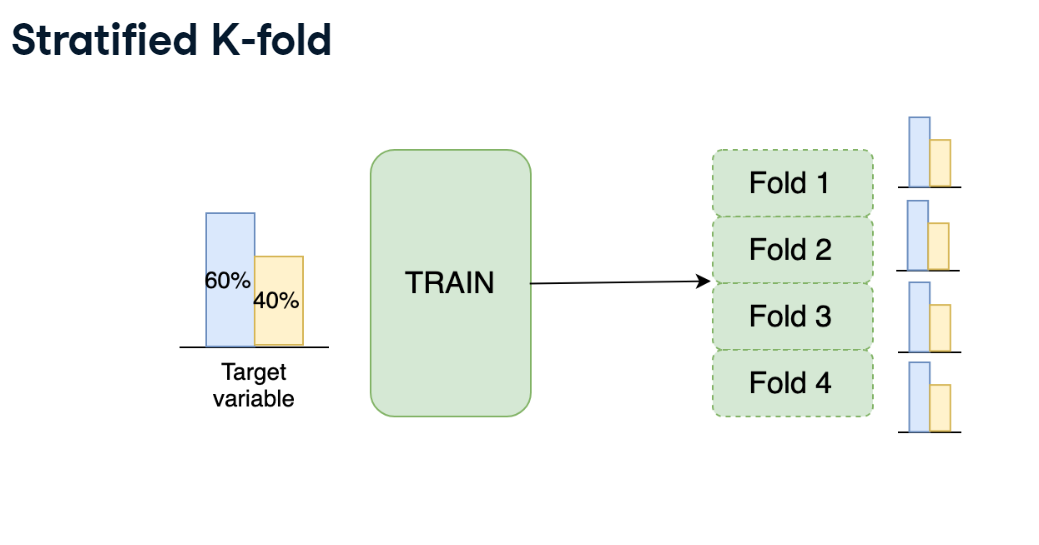

In [ ]:
Image('/content/pics/stratified_kfold.png')

In [ ]:
model_xg = XGBClassifier(random_state=42, objective='binary:logistic')

In [ ]:
param_grid_1 = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [ ]:
# Задаём разбиение данных на трейн и тест 3 раз. Для каждого такого разбиения будет
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
grid_search_1 = GridSearchCV(
    estimator=model_xg,
    param_grid=param_grid_1,
    scoring="accuracy",
    cv=kfold,
    n_jobs=-1,
)
grid_result_1 = grid_search_1.fit(X_train, y_train,
            eval_set=[(X_valid, y_valid)],
                                 verbose=False)

In [ ]:
grid_result_1.best_score_

np.float64(0.8295880149812734)

In [ ]:
grid_result_1.best_params_

{'colsample_bytree': 0.7,
 'learning_rate': 0.05,
 'max_depth': 4,
 'min_child_weight': 1,
 'n_estimators': 100,
 'subsample': 0.8}

In [ ]:
# Строим предсказание модели на валидационной выборке с учетом подобранных параметров
y_pred_best = grid_search_1.predict(X_valid)
print(classification_report(y_valid, y_pred_best))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       112
           1       0.79      0.70      0.74        66

    accuracy                           0.82       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.82      0.82      0.82       178



> По модели XGB после подбора параметров небольшие улучшения
- Основная метрика accuracy - 0.84.
- Средний взвешенный f1-score - 0.84.

In [ ]:
# Строим предсказание модели на тренировочной выборке с учетом подобранных параметров
y_pred_xg_train = grid_search_1.predict(X_train)
print(classification_report(y_train, y_pred_xg_train))

              precision    recall  f1-score   support

           0       0.86      0.95      0.91       332
           1       0.91      0.75      0.82       202

    accuracy                           0.88       534
   macro avg       0.89      0.85      0.86       534
weighted avg       0.88      0.88      0.87       534



# Раздел 5. Предсказание на новых данных

In [ ]:
# Строим предсказание модели на тестовой выборке с учетом подобранных параметров
y_pred_xg_ft = grid_search_1.predict(X_test)
print(classification_report(y_test, y_pred_xg_ft))

              precision    recall  f1-score   support

           0       0.82      0.90      0.85       105
           1       0.83      0.72      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



Разрыв между метриками на трейне, валидации и тесте около 4% (0.88, 0.84, 0.80). Для малого датасета это нормальное поведение.

По значениям метрик на разных выборках можно сделать вывод о процессе обучения. На что можно ориентироваться?

* accuracy train >= accuracy val ≈ accuracy test - обучение

* accuracy train >> accuracy val >= accuracy test - переобучение

* accuracy train ≈ accuracy val ≈ accuracy test - недообучение

По результатам оценки можно сделать вывод, о том, что получилась довольно качественная модель.

Такую модель смело можно использовать для предсказания, но важно помнить, что при предсказании могут быть ошибки (процент ошибок как раз и определяется подсчитанными метриками качества).

**Пример**: В октябре 2020 года шотландский футбольный клуб Inverness Caledonian
Thistle FC объявил, что его домашние игры будут транслироваться в прямом
эфире благодаря недавно установленной системе камер Pixellot на базе
искусственного интеллекта. Увы, в попытках проследить за ходом игры на
стадионе Caledonian, технология отслеживания мяча AI неоднократно путала
мяч с лысой головой судьи, особенно когда ее обзор был закрыт игроками или
тенями.

Вспоминаем, что на самом деле хотим не просто разметку на классы, а разметку с учетом вероятности. Для этого меняем метод, с помощью которого делаем предсказание.

In [ ]:
# # Если хотим предсказывать вероятность принадлености к классу, используем метод predict_proba вместо predict
y_pred_xg_best_prob = grid_search_1.predict_proba(X_test)[:,1]

In [ ]:
pd.DataFrame({'Предсказанные значения': y_pred_xg_best_prob }).sort_values(by='Предсказанные значения', ascending=False)

,Предсказанные значения
121,0.969032
87,0.968736
136,0.968533
112,0.967018
163,0.965029
...,...
80,0.057086
169,0.052587
103,0.049109
48,0.048978


Далее можно подбирать пороговое значение вероятности, по которому будем делить клиентов на классы. Но об этом в другой раз.

# Результаты проекта
---

Итак, на текущем этапе мы разобрались как **адаптировать результаты моделирования** к бизнес-задаче и как **сделать прогноз модели удобным для использования**. <br>
Проект в текущий момент **внедрен в продуктив** и активно используется для поиска лидов. Кроме того, как мы уже отметили, модель и фильтры на итоговый список итерационно обновляются в зависимости от обратной связи от менеджеров.

Давайте разберемся, какие преимущества от внедрения проекта мы получили.

## Преимущества нового подхода в поиске потенциальных клиентов

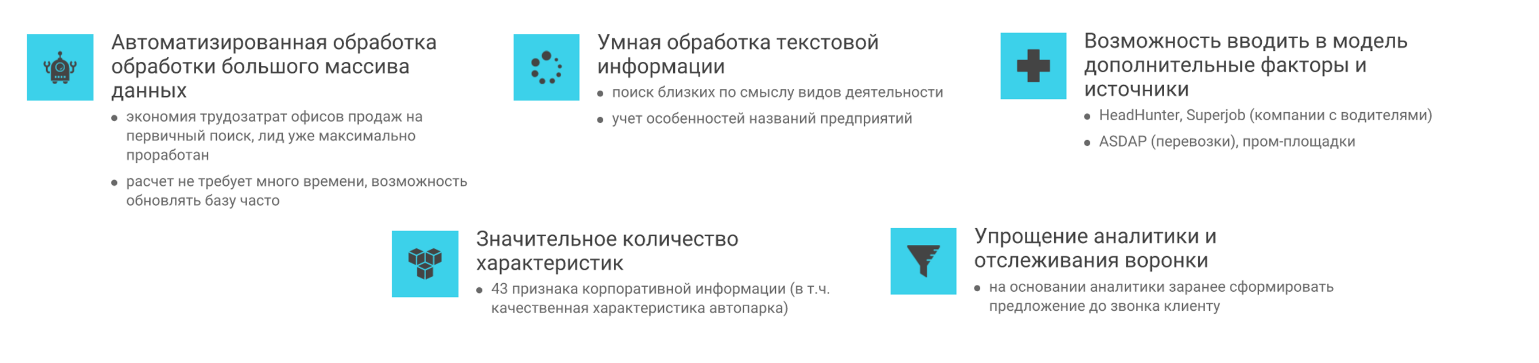

In [ ]:
Image('/content/pics/Преимущества.png')

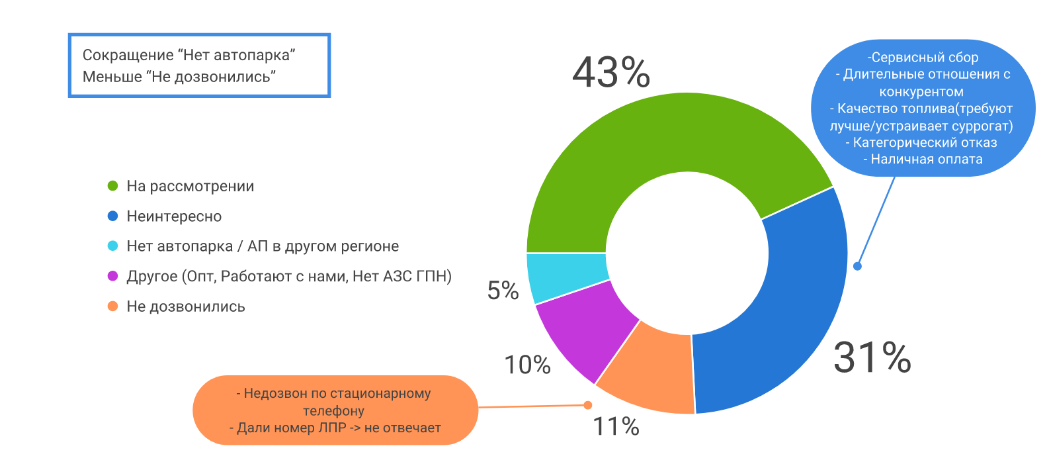

In [ ]:
Image('/content/pics/Результаты.png')

## Эффекты от использования списка лидов, полученных в рамках проекта

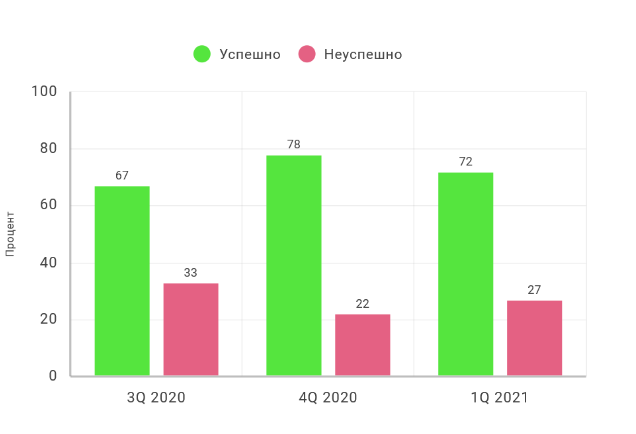

In [ ]:
Image('/content/pics/Эффекты.png')